# Agile Bioacoustic Modeling with SongSpace

This tutorial reproduces the core iterative workflow from the Hoplite agile modeling notebook, but uses `SongSpace` to manage datasets and shallow classifiers.

## Run this tutorial

If running in Colab, uncomment the installation line below.

In [1]:
# if 'google.colab' in str(get_ipython()):
#     %pip install "opensoundscape==0.12.1" "bioacoustics-model-zoo==0.12.0"

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import bioacoustics_model_zoo as bmz

from opensoundscape.annotations import BoxedAnnotations
from opensoundscape.vector_database import load_or_create_hoplite_usearch_db
from opensoundscape.ml.song_space import SongSpace
from opensoundscape.ml.shallow_classifier import select_from_hoplite
from opensoundscape.visualization import annotate, inspect

## Prepare labels

This uses the same _Rana sierrae_ example files as the agile Hoplite tutorial.

In [2]:
dataset_path = Path("./rana_sierrae_2022/")
audio_and_raven_files = pd.read_csv(dataset_path / "audio_and_raven_files.csv")
audio_and_raven_files["audio"] = audio_and_raven_files["audio"].apply(
    lambda x: str(dataset_path / x)
)
audio_and_raven_files["raven"] = audio_and_raven_files["raven"].apply(
    lambda x: str(dataset_path / x)
)

annotations = BoxedAnnotations.from_raven_files(
    raven_files=audio_and_raven_files["raven"],
    audio_files=audio_and_raven_files["audio"],
    annotation_column="annotation",
)

labels = annotations.clip_labels(clip_duration=3, min_label_overlap=0.2)

/Users/SML161/opensoundscape/opensoundscape/annotations.py:347: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_annotations_df = pd.concat(all_file_dfs).reset_index(drop=True)


In [3]:
target_source_class = "C"
target_model_class = "RanaSierrae_C"

# start with one recording of target class
binary_labels = labels[[target_source_class]].rename(
    columns={target_source_class: target_model_class}
)
seed_train = binary_labels.loc[
    ["rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220623_060000_0-10s.mp3"]
]
other = binary_labels.drop(seed_train.index)
validation, unlabeled = train_test_split(other, test_size=0.8, random_state=0)

print("seed_train:", seed_train.shape)
print("validation:", validation.shape)
print("pool:", unlabeled.shape)

seed_train: (4, 1)
validation: (536, 1)
pool: (2148, 1)


All audio clips from the single audio file we'll start with for positives:


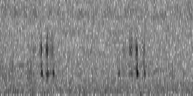
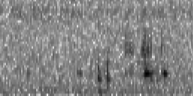
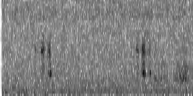
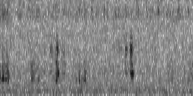

In [4]:
_ = inspect(seed_train, bandpass_range=(0, 2500))

In [5]:
import opensoundscape as opso

## Build database and SongSpace

In [6]:
ss = SongSpace("./Perch2SongSpace", feature_extractor="perch2")

/Users/SML161/miniconda3/envs/opso_dev/lib/python3.13/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Connecting to existing db at Perch2SongSpace
Connected database has 2,691 embeddings from 672 files.


/Users/SML161/miniconda3/envs/opso_dev/lib/python3.13/site-packages/bioacoustics_model_zoo/perch_v2.py:208: UserWarning: Disabling TensorFlow's XLA compilation (setting tf.config.optimizer.set_jit(False)) because otherwise TF models on Mac hang at runtime as of Tensorflow 2.21.0
  warnings.warn(


In [7]:
import opensoundscape as opso

opso.set_seed(0)

In [8]:
# Embed and register datasets in SongSpace.
ss.ingest_audio(
    seed_train,
    dataset_name="round1_train",
    batch_size=32,
)
ss.ingest_audio(
    validation,
    dataset_name="validation",
    allow_training=False,
    batch_size=32,
)
ss.ingest_audio(
    unlabeled,
    dataset_name="pool_unlabeled",
    batch_size=32,
)

ss.list_datasets()

all samples already have embeddings in the database
all samples already have embeddings in the database
all samples already have embeddings in the database


['round1_train', 'validation', 'pool_unlabeled']

In [9]:
ss.save()

Saved SongSpace to ./Perch2SongSpace with 0 classifiers and 3 datasets.


## Similarity search for similar samples

In [10]:
# Similarity search
matches_for_each_query = ss.similarity_search(seed_train, k=20, exact_search=True)
best_matches = matches_for_each_query.sort_values(
    by="sort_score", ascending=False
).head(20)
# Review and annotate interactively.
_ = annotate(
    best_matches,
    bandpass_range=(0, 2500),
    annotation_buttons=["Accept", "Reject"],
    N=20,
)

embedding query samples


/Users/SML161/opensoundscape/opensoundscape/ml/cnn.py:2958: UserWarning: The columns of input samples df differ from `model.classes`. Discarding sample df columns.
  warnings.warn(


  0%|          | 0/4 [00:00<?, ?it/s]

I0000 00:00:1777739717.752267 187792319 service.cc:153] XLA service 0x345dad280 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777739717.752300 187792319 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1777739717.990144 187792319 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1777739718.379899 187812932 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
I0000 00:00:1777739718.380410 187812932 rsqrt.cc:179] Falling back to 1 / sqrt(x) for f32 false
I0000 00:00:1777739718.699683 187792319 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


performing similarity search for each of 4 query samples


GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

In [11]:
# ingest labels from the interactive labeling widget
new_pos = best_matches[best_matches["Accept"] == True][
    ["file", "start_time", "end_time"]
].copy()
new_pos[target_model_class] = 1

new_neg = best_matches[best_matches["Reject"] == True][
    ["file", "start_time", "end_time"]
].copy()
new_neg[target_model_class] = 0

search_labels = (
    pd.concat([new_pos, new_neg], ignore_index=True)
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])[[target_model_class]]
)

# add these labels to their own dataset in the SongSpace
ss.ingest_audio(
    search_labels,
    dataset_name="search_labels",
    batch_size=32,
    num_workers=0,
)

ss.save()

search_labels[target_model_class].value_counts()

Saved SongSpace to ./Perch2SongSpace with 0 classifiers and 4 datasets.


Series([], Name: count, dtype: int64)

## Train first classifier

In [16]:
clf_round1.classes

['RanaSierrae_C']

In [19]:
clf_round1 = ss.fit_classifier(
    classes=[target_model_class],
    train_datasets=["round1_train", "search_labels"],
    validation_dataset="validation",
    weak_negatives_proportion=20.0,  # lots of weak negatives, since we have just a few positives!
    weak_negatives_weight=0.01,
    steps=100,
    batch_size=128,
    validation_interval=50,
    logging_interval=50,
)
clf_round1.val_metrics

training classifier for 1 classes with 4 training samples and 536 validation samples
Finding matching window IDs for samples in label_df...
Finding matching window IDs for samples in label_df...
Epoch 50/100, Loss: 0.032, Val Loss: 1.808
	val AU ROC: 0.818
	val MAP: 0.380
Epoch 100/100, Loss: 0.013, Val Loss: 2.196
	val AU ROC: 0.815
	val MAP: 0.384
Loaded best model with validation loss: 1.808 at step 50 of 100
Training complete


{'loss': 1.808026337623596,
 'auroc': 0.8152555820015869,
 'map': 0.38365875257605436,
 'per_class_auroc': [0.8152555820015869]}

save the classifier in the SoundScape, if we like it enough

In [22]:
if "rana_round1" in ss.list_classifiers():
    ss.remove_classifier("rana_round1")
ss.add_classifier("rana_round1", clf_round1)
ss.save()

Saved SongSpace to ./Perch2SongSpace with 1 classifiers and 4 datasets.


evaluate a saved classifier on a specific dataset

In [23]:
round1_metrics = ss.evaluate("rana_round1", "validation")
round1_metrics

Finding matching window IDs for samples in label_df...


{'RanaSierrae_C': {'average_precision': 0.38365875257605436,
  'roc_auc': 0.8152555820015869},
 'macro_average_precision': np.float64(0.38365875257605436),
 'macro_roc_auc': np.float64(0.8152555820015869)}

## Active learning round: review high-scoring candidates

In [24]:
pool_scores = ss.predict_on_dataset(
    classifier_name="rana_round1", dataset_name="pool_unlabeled"
)
# drop samples already labeled
labeled_idx = set(search_labels.index).union(set(seed_train.index))
pool_scores = pool_scores[~pool_scores.index.isin(labeled_idx)]
topk = pool_scores.nlargest(20, target_model_class).reset_index()

# Review and annotate interactively.
_ = annotate(
    topk, bandpass_range=(0, 2500), annotation_buttons=["Accept", "Reject"], N=20
)
topk.head()

Finding matching window IDs for samples in label_df...


GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

,file,start_time,end_time,RanaSierrae_C,Accept,Reject
0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,4.019656,None,None
1,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,3.911836,None,None
2,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,3.696870,None,None
3,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,9.0,12.0,3.689356,None,None
4,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,3.676516,None,None


ingest labels

In [25]:
new_pos = topk[topk["Accept"] == True][["file", "start_time", "end_time"]].copy()
new_pos[target_model_class] = 1

new_neg = topk[topk["Reject"] == True][["file", "start_time", "end_time"]].copy()
new_neg[target_model_class] = 0

round2_train = (
    pd.concat([new_pos, new_neg], ignore_index=True)
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])[[target_model_class]]
)

ss.ingest_audio(
    round2_train,
    dataset_name="round2_train",
    batch_size=32,
    num_workers=0,
)
ss.save()
round2_train[target_model_class].value_counts()

all samples already have embeddings in the database
Saved SongSpace to ./Perch2SongSpace with 1 classifiers and 5 datasets.


RanaSierrae_C
1    7
0    4
Name: count, dtype: int64

## build a new classifier

In [26]:
clf_round2 = ss.fit_classifier(
    classes=[target_model_class],
    train_datasets=["round1_train", "search_labels", "round2_train"],
    validation_dataset="validation",
    weak_negatives_proportion=1.0,
    weak_negatives_weight=0.001,
    steps=200,
    batch_size=128,
    validation_interval=30,
    logging_interval=30,
)
if "rana_round2" in ss.list_classifiers():
    ss.remove_classifier("rana_round2")
ss.add_classifier("rana_round2", clf_round2)

round2_metrics = ss.evaluate("rana_round2", "validation")
round2_metrics

training classifier for 1 classes with 15 training samples and 536 validation samples
Finding matching window IDs for samples in label_df...
Finding matching window IDs for samples in label_df...
Epoch 30/200, Loss: 0.310, Val Loss: 0.894
	val AU ROC: 0.810
	val MAP: 0.520
Epoch 60/200, Loss: 0.171, Val Loss: 0.924
	val AU ROC: 0.796
	val MAP: 0.501
Epoch 90/200, Loss: 0.109, Val Loss: 0.969
	val AU ROC: 0.792
	val MAP: 0.460
Epoch 120/200, Loss: 0.077, Val Loss: 1.014
	val AU ROC: 0.788
	val MAP: 0.453
Epoch 150/200, Loss: 0.058, Val Loss: 1.053
	val AU ROC: 0.786
	val MAP: 0.456
Epoch 180/200, Loss: 0.045, Val Loss: 1.090
	val AU ROC: 0.783
	val MAP: 0.438
Loaded best model with validation loss: 0.894 at step 30 of 200
Training complete
Finding matching window IDs for samples in label_df...


{'RanaSierrae_C': {'average_precision': 0.4372028615086696,
  'roc_auc': 0.7822736030828517},
 'macro_average_precision': np.float64(0.4372028615086696),
 'macro_roc_auc': np.float64(0.7822736030828517)}

## Active learning round 2: review high-scoring candidates

In [27]:
pool_scores = ss.predict_on_dataset(
    classifier_name="rana_round2", dataset_name="pool_unlabeled"
)
# drop samples already labeled
labeled_idx = (
    set(search_labels.index).union(set(seed_train.index)).union(set(round2_train.index))
)
pool_scores = pool_scores[~pool_scores.index.isin(labeled_idx)]
topk = pool_scores.nlargest(20, target_model_class).reset_index()

# Review and annotate interactively.
_ = annotate(
    topk, bandpass_range=(0, 2500), annotation_buttons=["Accept", "Reject"], N=20
)
topk.head()

Finding matching window IDs for samples in label_df...


GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

,file,start_time,end_time,RanaSierrae_C,Accept,Reject
0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,4.586790,None,None
1,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,4.581011,None,None
2,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,4.341825,None,None
3,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,9.0,12.0,4.322948,None,None
4,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,4.015476,None,None


ingest labels

In [28]:
new_pos = topk[topk["Accept"] == True][["file", "start_time", "end_time"]].copy()
new_pos[target_model_class] = 1

new_neg = topk[topk["Reject"] == True][["file", "start_time", "end_time"]].copy()
new_neg[target_model_class] = 0

round3_train = (
    pd.concat([new_pos, new_neg], ignore_index=True)
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])[[target_model_class]]
)

ss.ingest_audio(
    round3_train,
    dataset_name="round3_train",
    batch_size=32,
    num_workers=0,
)
ss.save()
round3_train[target_model_class].value_counts()

all samples already have embeddings in the database
Saved SongSpace to ./Perch2SongSpace with 2 classifiers and 6 datasets.


RanaSierrae_C
0    6
1    5
Name: count, dtype: int64

build new classifier

In [29]:
clf_round3 = ss.fit_classifier(
    classes=[target_model_class],
    train_datasets=["round1_train", "search_labels", "round2_train", "round3_train"],
    validation_dataset="validation",
    weak_negatives_proportion=1.0,
    weak_negatives_weight=0.001,
    steps=200,
    batch_size=128,
    validation_interval=30,
    logging_interval=30,
)
if "rana_round3" in ss.list_classifiers():
    ss.remove_classifier("rana_round3")
ss.add_classifier("rana_round3", clf_round3)

ss.save()

round3_metrics = ss.evaluate("rana_round3", "validation")
round3_metrics

training classifier for 1 classes with 26 training samples and 536 validation samples
Finding matching window IDs for samples in label_df...
Finding matching window IDs for samples in label_df...
Epoch 30/200, Loss: 0.444, Val Loss: 0.563
	val AU ROC: 0.869
	val MAP: 0.568
Epoch 60/200, Loss: 0.316, Val Loss: 0.440
	val AU ROC: 0.887
	val MAP: 0.554
Epoch 90/200, Loss: 0.240, Val Loss: 0.374
	val AU ROC: 0.897
	val MAP: 0.531
Epoch 120/200, Loss: 0.188, Val Loss: 0.337
	val AU ROC: 0.898
	val MAP: 0.530
Epoch 150/200, Loss: 0.151, Val Loss: 0.313
	val AU ROC: 0.895
	val MAP: 0.520
Epoch 180/200, Loss: 0.123, Val Loss: 0.297
	val AU ROC: 0.892
	val MAP: 0.514
Loaded best model with validation loss: 0.297 at step 180 of 200
Training complete
Saved SongSpace to ./Perch2SongSpace with 3 classifiers and 6 datasets.
Finding matching window IDs for samples in label_df...


{'RanaSierrae_C': {'average_precision': 0.5119285905987927,
  'roc_auc': 0.8918735124107446},
 'macro_average_precision': np.float64(0.5119285905987927),
 'macro_roc_auc': np.float64(0.8918735124107446)}

we now have a solid classifier to use for downstream tasks.

## Select clips for manual verification

Use stratified or thresholded selection from the full embedded database.

For example, here we select 20 clips using the most recent classifier

We can also do this in another Python session by re-opening the SongSpace, which will retain all the classifier, labels, and embeddings.

In [30]:
ss_reloaded = SongSpace.open("./Perch2SongSpace")
print(f"Classifiers: {ss_reloaded.list_classifiers()}")
print(f"Datasets: {ss_reloaded.list_datasets()}")

Connecting to existing db at Perch2SongSpace
Connected database has 2,691 embeddings from 672 files.
Classifiers: ['rana_round1', 'rana_round2', 'rana_round3']
Datasets: ['round1_train', 'validation', 'pool_unlabeled', 'search_labels', 'round2_train', 'round3_train']


/Users/SML161/miniconda3/envs/opso_dev/lib/python3.13/site-packages/bioacoustics_model_zoo/perch_v2.py:208: UserWarning: Disabling TensorFlow's XLA compilation (setting tf.config.optimizer.set_jit(False)) because otherwise TF models on Mac hang at runtime as of Tensorflow 2.21.0
  warnings.warn(


('2022-06-20', '2022-06-21')



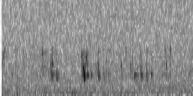
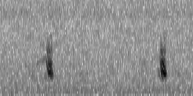

('2022-06-22', '2022-06-23')



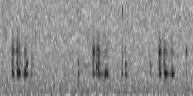
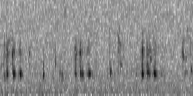

('2022-06-24', '2022-06-25')



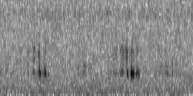
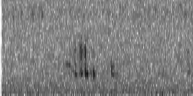

('2022-06-26', '2022-06-27')



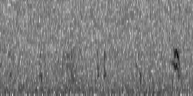
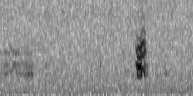

In [32]:
date_ranges = [
    ("2022-06-20", "2022-06-21"),
    ("2022-06-22", "2022-06-23"),
    ("2022-06-24", "2022-06-25"),
    ("2022-06-26", "2022-06-27"),
]
clips_per_date = []

for i, date_range in enumerate(date_ranges):
    selected = select_from_hoplite(
        ss_reloaded.db,
        ss_reloaded.classifiers["rana_round3"],
        classes=[target_model_class],
        strategy="top_k",
        k=2,
        min_score=0,
        date_range=date_range,
    )
    selected["visit"] = i + 1
    clips_per_date.append(selected)
    print(date_range)
    inspect(selected, bandpass_range=(0, 2500))

# table ready for Dipper review with stratification by "visit"
clips_for_review = pd.concat(clips_per_date).reset_index(drop=True)

In [33]:
# Optional cleanup
# import shutil
# shutil.rmtree('./songspace_agile_db/')